# Summary Visualizations

Static manuscript-ready performance charts sourced from the final README comparison tables.


## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROPOSED_COLOR = "#2ca02c"
BASELINE_COLORS = ["#7f7f7f", "#1f77b4", "#ff7f0e", "#9467bd", "#8c564b"]
ATC_CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def annotate_bars(ax, fmt="{:.2f}", rotation=0, orientation="vertical"):
    for container in ax.containers:
        labels = [
            fmt.format(bar.get_width() if orientation == "horizontal" else bar.get_height())
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            rotation=rotation,
            color="white",
            fontweight="bold",
        )


## PharmaSales Daily RMSE


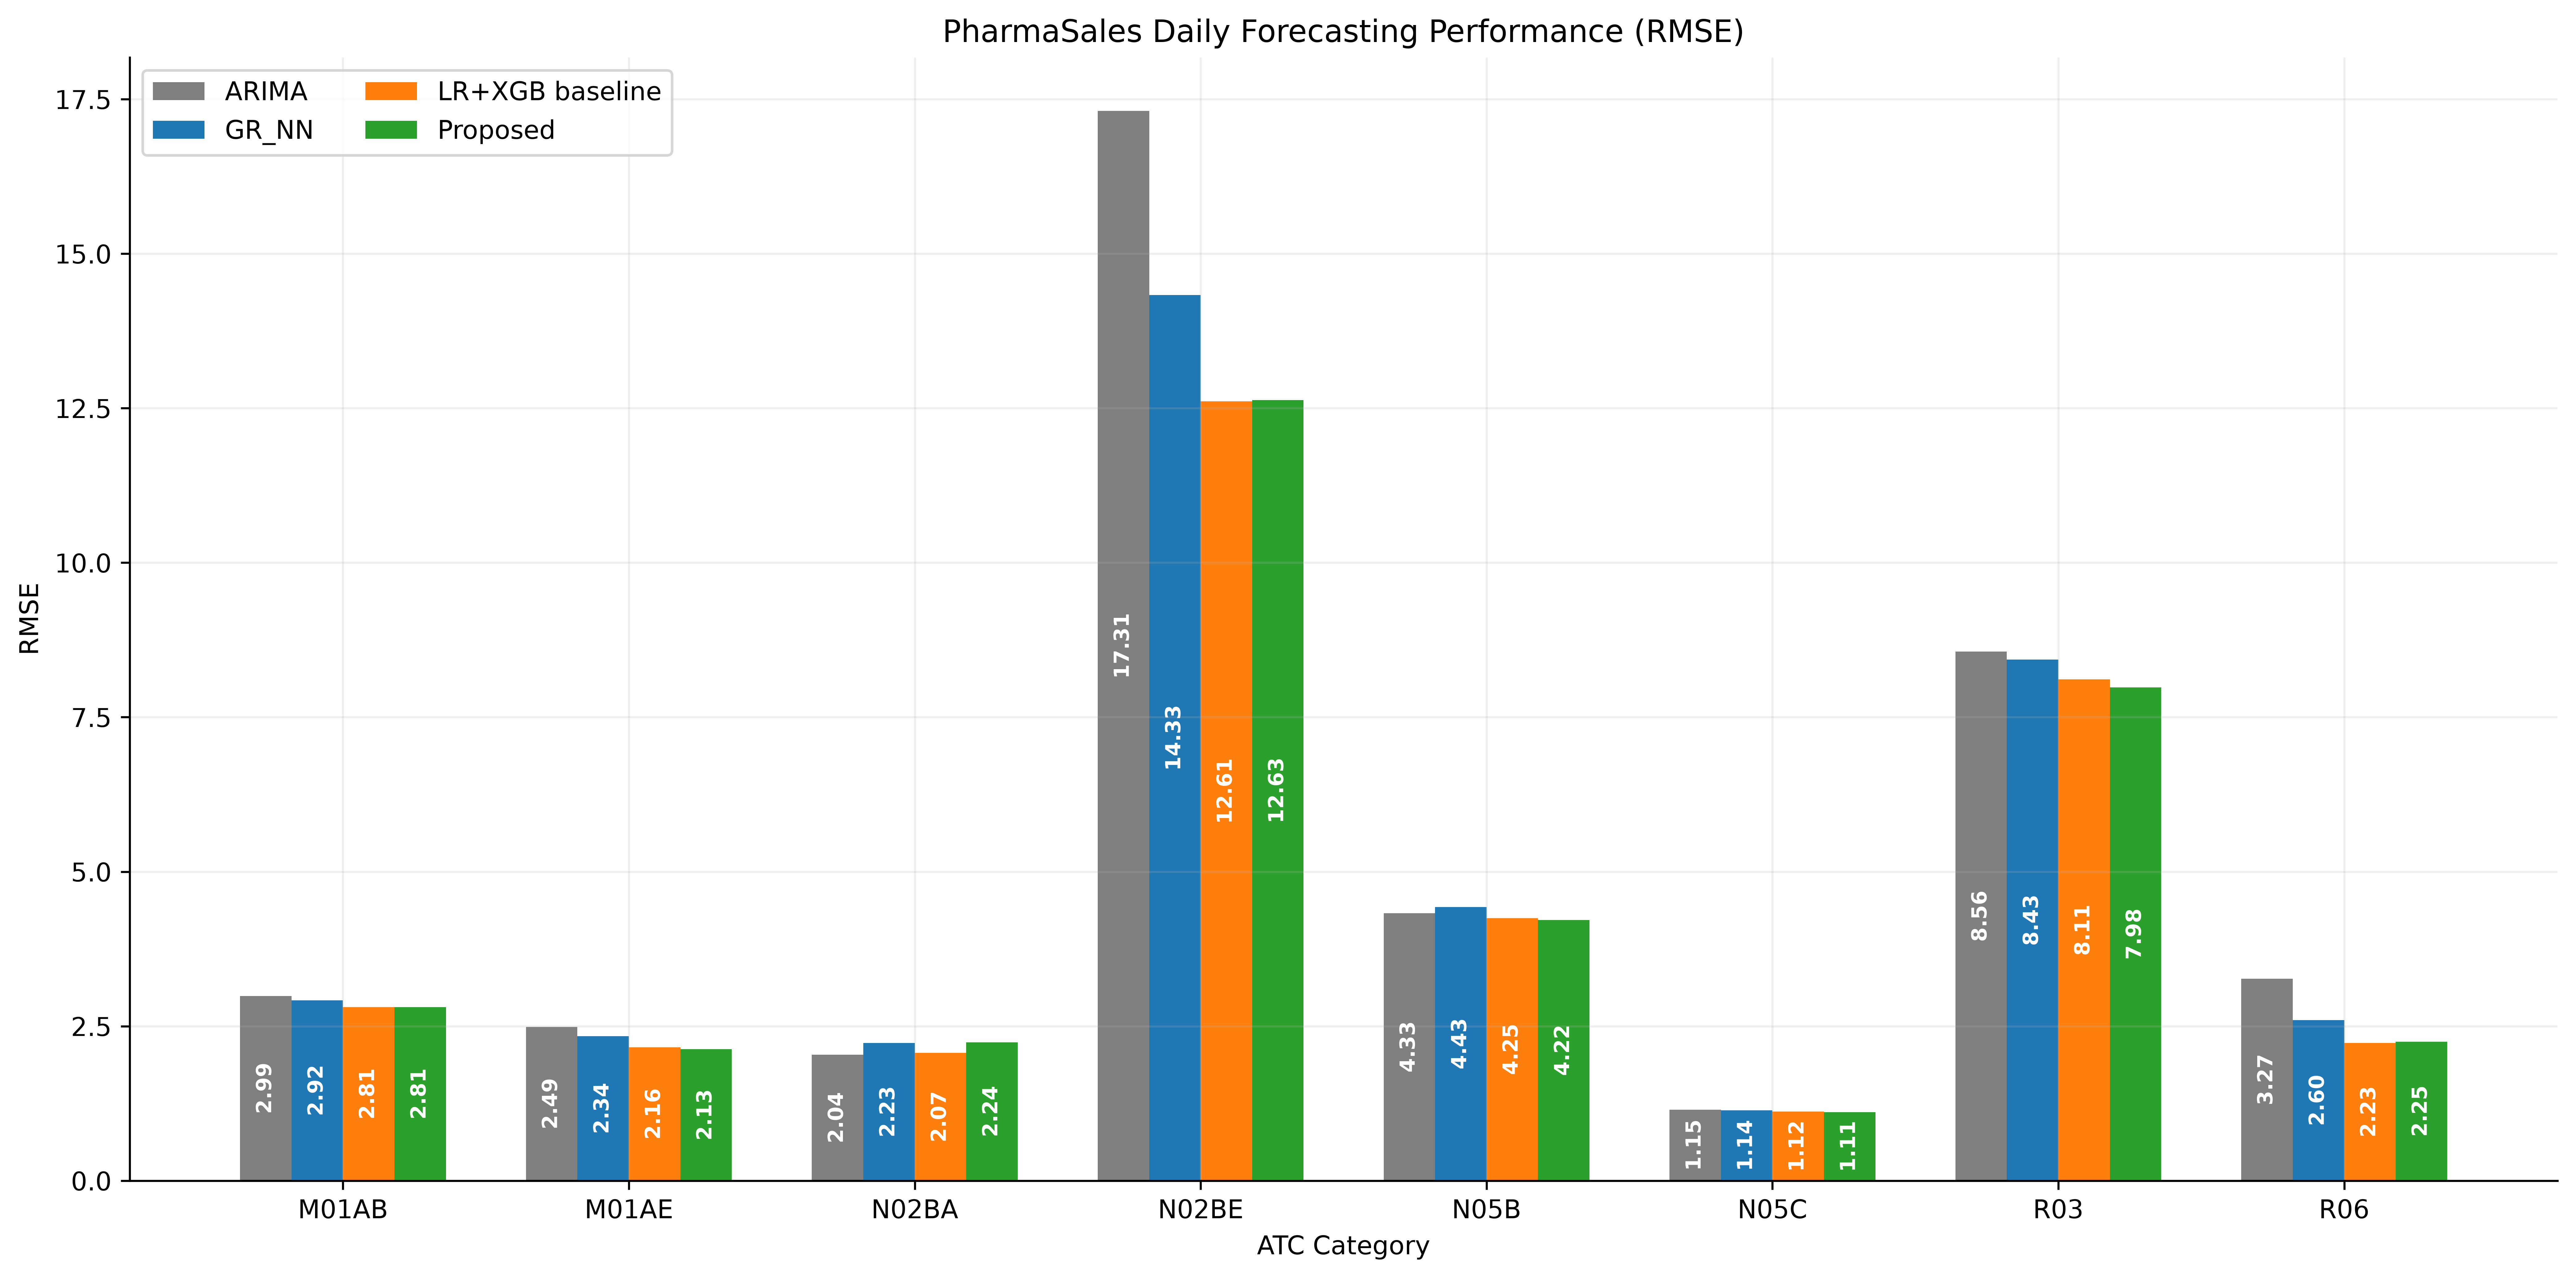

In [2]:
daily_rmse = pd.DataFrame({
    "Method": ["ARIMA", "GR_NN", "P_NN", "RBF_NN", "LR+XGB baseline", "Proposed"],
    "M01AB": [2.99, 2.92, 3.18, 2.93, 2.81, 2.81],
    "M01AE": [2.49, 2.34, 2.36, 2.30, 2.16, 2.22],
    "N02BA": [2.04, 2.23, 2.20, 2.24, 2.07, 2.19],
    "N02BE": [17.31, 14.33, 15.54, 14.51, 12.61, 13.84],
    "N05B": [4.33, 4.43, 6.16, 4.46, 4.25, 4.26],
    "N05C": [1.15, 1.14, 1.27, 1.15, 1.12, 1.11],
    "R03": [8.56, 8.43, 10.27, 8.43, 8.11, 8.51],
    "R06": [3.27, 2.60, 3.02, 2.58, 2.23, 2.40],
})

method_colors = {method: BASELINE_COLORS[idx % len(BASELINE_COLORS)] for idx, method in enumerate(daily_rmse["Method"])}
method_colors["Proposed"] = PROPOSED_COLOR
x = np.arange(len(ATC_CATEGORIES))
width = 0.14

fig, ax = plt.subplots(figsize=(14, 7), dpi=600)
for rank in range(5):
    values = []
    colors = []
    for category in ATC_CATEGORIES:
        top = daily_rmse[["Method", category]].sort_values(category).head(5).reset_index(drop=True)
        method = top.loc[rank, "Method"]
        values.append(top.loc[rank, category])
        colors.append(method_colors[method])
    ax.bar(x + (rank - 2) * width, values, width, color=colors)

ax.set_title("PharmaSales Daily Forecasting Performance (Top 5 RMSE per Category)")
ax.set_xlabel("ATC Category")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(ATC_CATEGORIES)
ax.legend(handles=[Patch(facecolor=method_colors[method], label=method) for method in daily_rmse["Method"]], loc="upper left", ncols=3)
annotate_bars(ax, fmt="{:.2f}", rotation=90)
plt.tight_layout()
plt.savefig("../assets/summary/pharma_daily_rmse.png", bbox_inches="tight")
plt.show()


## PharmaSales Weekly MSE


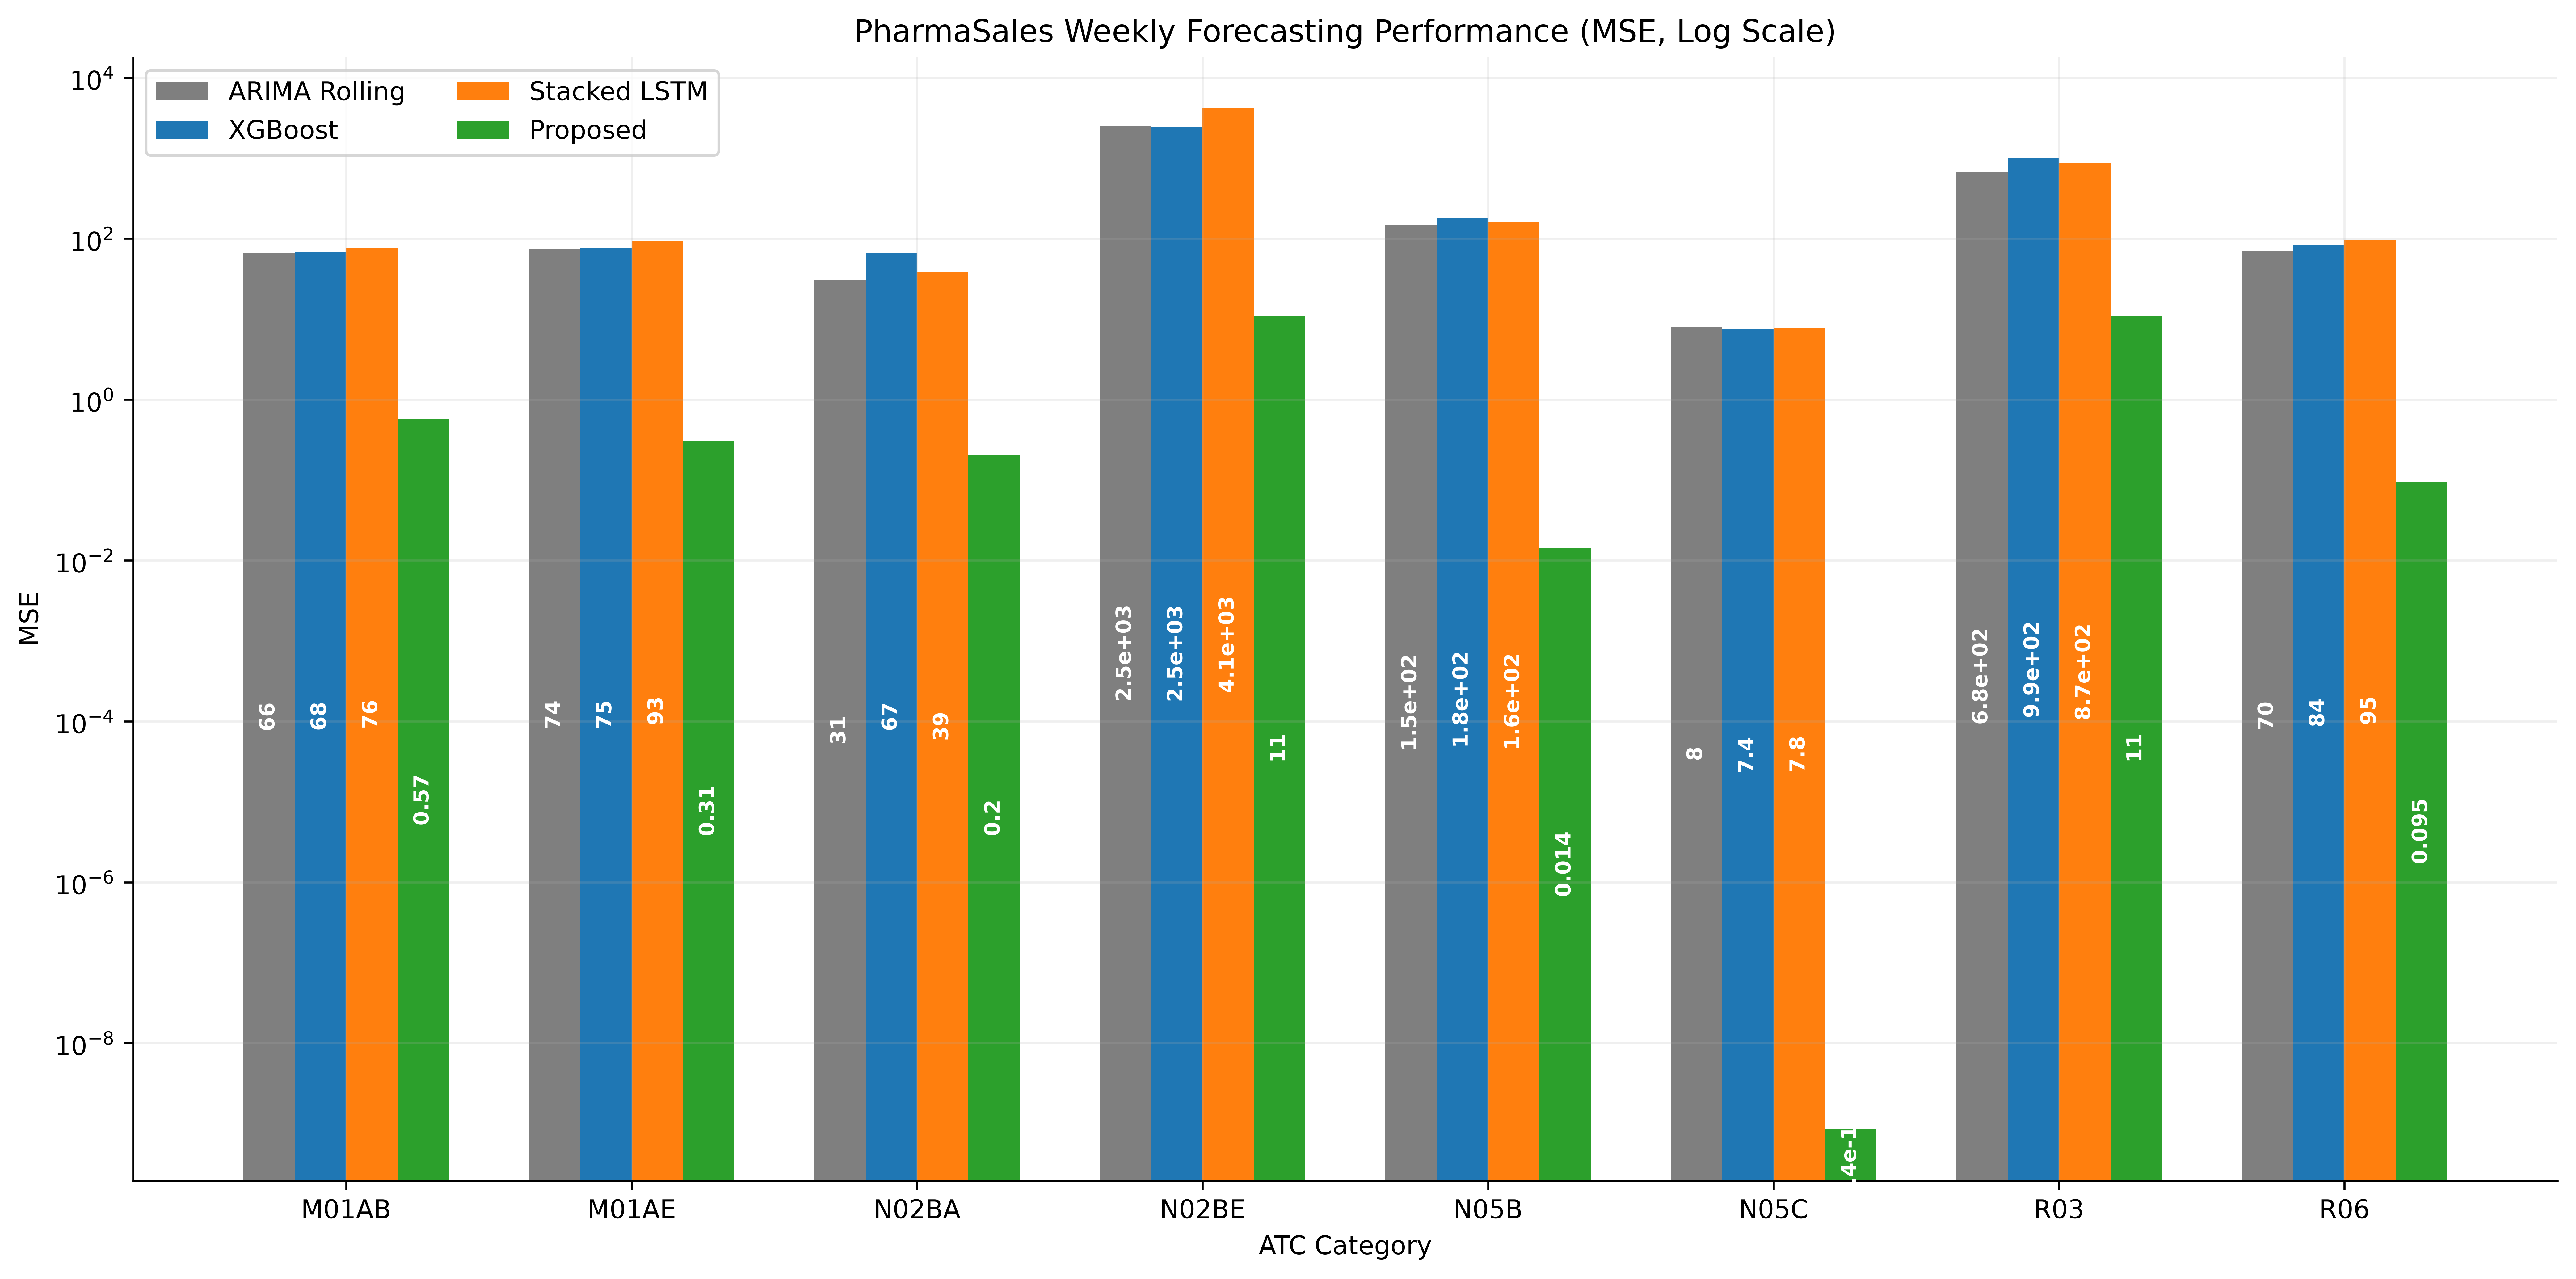

In [3]:
weekly_mse = pd.DataFrame({
    "Method": [
        "Seasonal Naive",
        "ARIMA",
        "ARIMA Rolling",
        "Auto-ARIMA",
        "Single Exp. Smoothing",
        "Double Exp. Smoothing",
        "Triple Exp. Smoothing",
        "FB Prophet",
        "XGBoost",
        "Stacked LSTM",
        "Proposed",
    ],
    "M01AB": [72.13, 80.17, 66.08, 68.95, 68.84, 65.15, 75.91, 89.19, 68.22, 76.29, 65.2072],
    "M01AE": [82.64, 86.96, 74.14, 86.47, 86.51, 87.30, 86.19, 75.67, 75.45, 93.25, 71.1793],
    "N02BA": [73.25, 50.86, 30.97, 29.03, 29.03, 36.36, 45.28, 44.03, 66.88, 38.54, 67.7600],
    "N02BE": [2357.23, 6888.53, 2525.41, 6834.85, 11483.95, 12352.55, 3197.90, 3541.74, 2470.51, 4145.11, 2472.6989],
    "N05B": [211.76, 160.47, 149.74, 156.12, 156.09, 139.13, 243.99, 248.06, 178.77, 158.71, 175.9400],
    "N05C": [11.11, 8.33, 7.99, 8.12, 8.06, 8.70, 9.28, 10.09, 7.44, 7.77, 8.1876],
    "R03": [1024.35, 1361.48, 677.92, 2287.68, 2279.65, 2362.09, 901.63, 807.72, 993.66, 866.70, 857.4368],
    "R06": [80.34, 117.72, 70.25, 120.88, 151.60, 159.27, 72.71, 73.03, 83.97, 94.91, 70.8699],
})

method_colors = {method: BASELINE_COLORS[idx % len(BASELINE_COLORS)] for idx, method in enumerate(weekly_mse["Method"])}
method_colors["Proposed"] = PROPOSED_COLOR
x = np.arange(len(ATC_CATEGORIES))
width = 0.14

fig, ax = plt.subplots(figsize=(14, 7), dpi=600)
for rank in range(5):
    values = []
    colors = []
    for category in ATC_CATEGORIES:
        top = weekly_mse[["Method", category]].sort_values(category).head(5).reset_index(drop=True)
        method = top.loc[rank, "Method"]
        values.append(top.loc[rank, category])
        colors.append(method_colors[method])
    ax.bar(x + (rank - 2) * width, values, width, color=colors)

ax.set_title("PharmaSales Weekly Forecasting Performance (Top 5 MSE per Category, Log Scale)")
ax.set_xlabel("ATC Category")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(ATC_CATEGORIES)
ax.legend(handles=[Patch(facecolor=method_colors[method], label=method) for method in weekly_mse["Method"]], loc="upper left", ncols=3, fontsize=8)
annotate_bars(ax, fmt="{:.2g}", rotation=90)
plt.tight_layout()
plt.savefig("../assets/summary/pharma_weekly_mse.png", bbox_inches="tight")
plt.show()


## Rossmann Original Scale RMSE


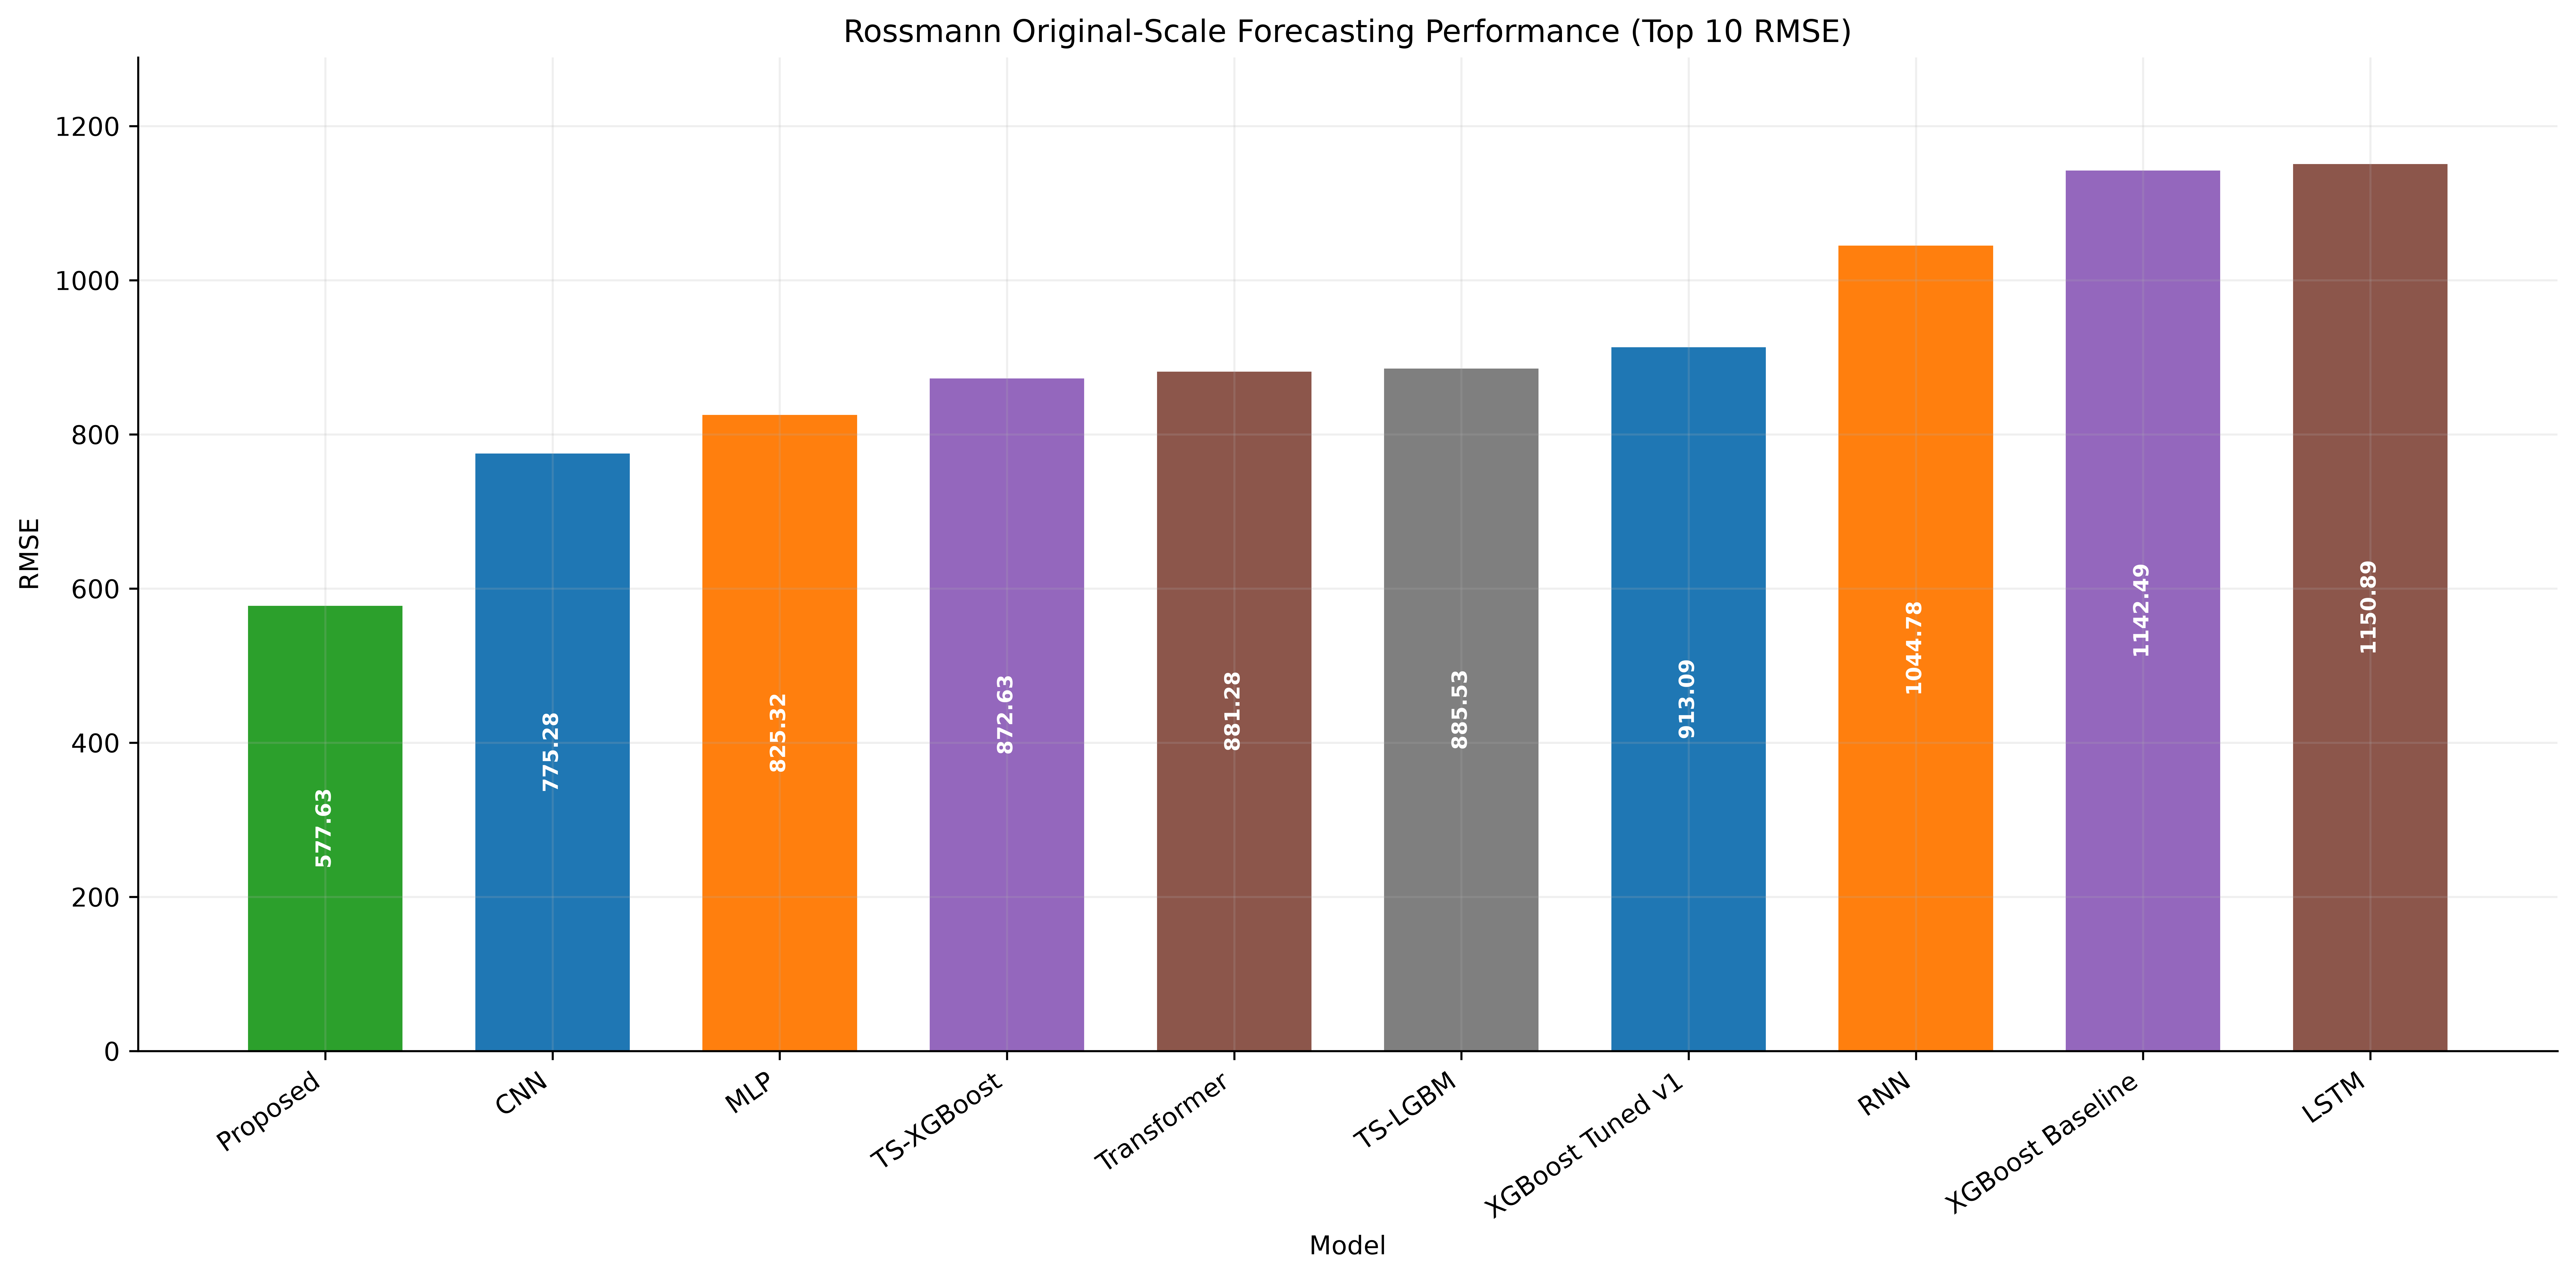

In [4]:
rossmann_original_rmse = pd.DataFrame({
    "Model": [
        "Proposed",
        "CNN",
        "MLP",
        "TS-XGBoost",
        "Transformer",
        "TS-LGBM",
        "XGBoost Tuned v1",
        "RNN",
        "XGBoost Baseline",
        "LSTM",
    ],
    "RMSE": [577.63, 775.28, 825.32, 872.63, 881.28, 885.53, 913.09, 1044.78, 1142.49, 1150.89],
})

colors = [PROPOSED_COLOR if model == "Proposed" else BASELINE_COLORS[idx % len(BASELINE_COLORS)] for idx, model in enumerate(rossmann_original_rmse["Model"])]
x = np.arange(len(rossmann_original_rmse))
fig, ax = plt.subplots(figsize=(14, 7), dpi=600)
bars = ax.bar(x, rossmann_original_rmse["RMSE"], width=0.68, color=colors)
ax.set_title("Rossmann Original-Scale Forecasting Performance (Top 10 RMSE)")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(rossmann_original_rmse["Model"], rotation=35, ha="right")
ax.set_ylim(0, rossmann_original_rmse["RMSE"].max() * 1.12)
annotate_bars(ax, fmt="{:.2f}", rotation=90)
plt.tight_layout()
plt.savefig("../assets/summary/rossmann_original_rmse.png", bbox_inches="tight")
plt.show()


## Rossmann Log-Transformed RMSE


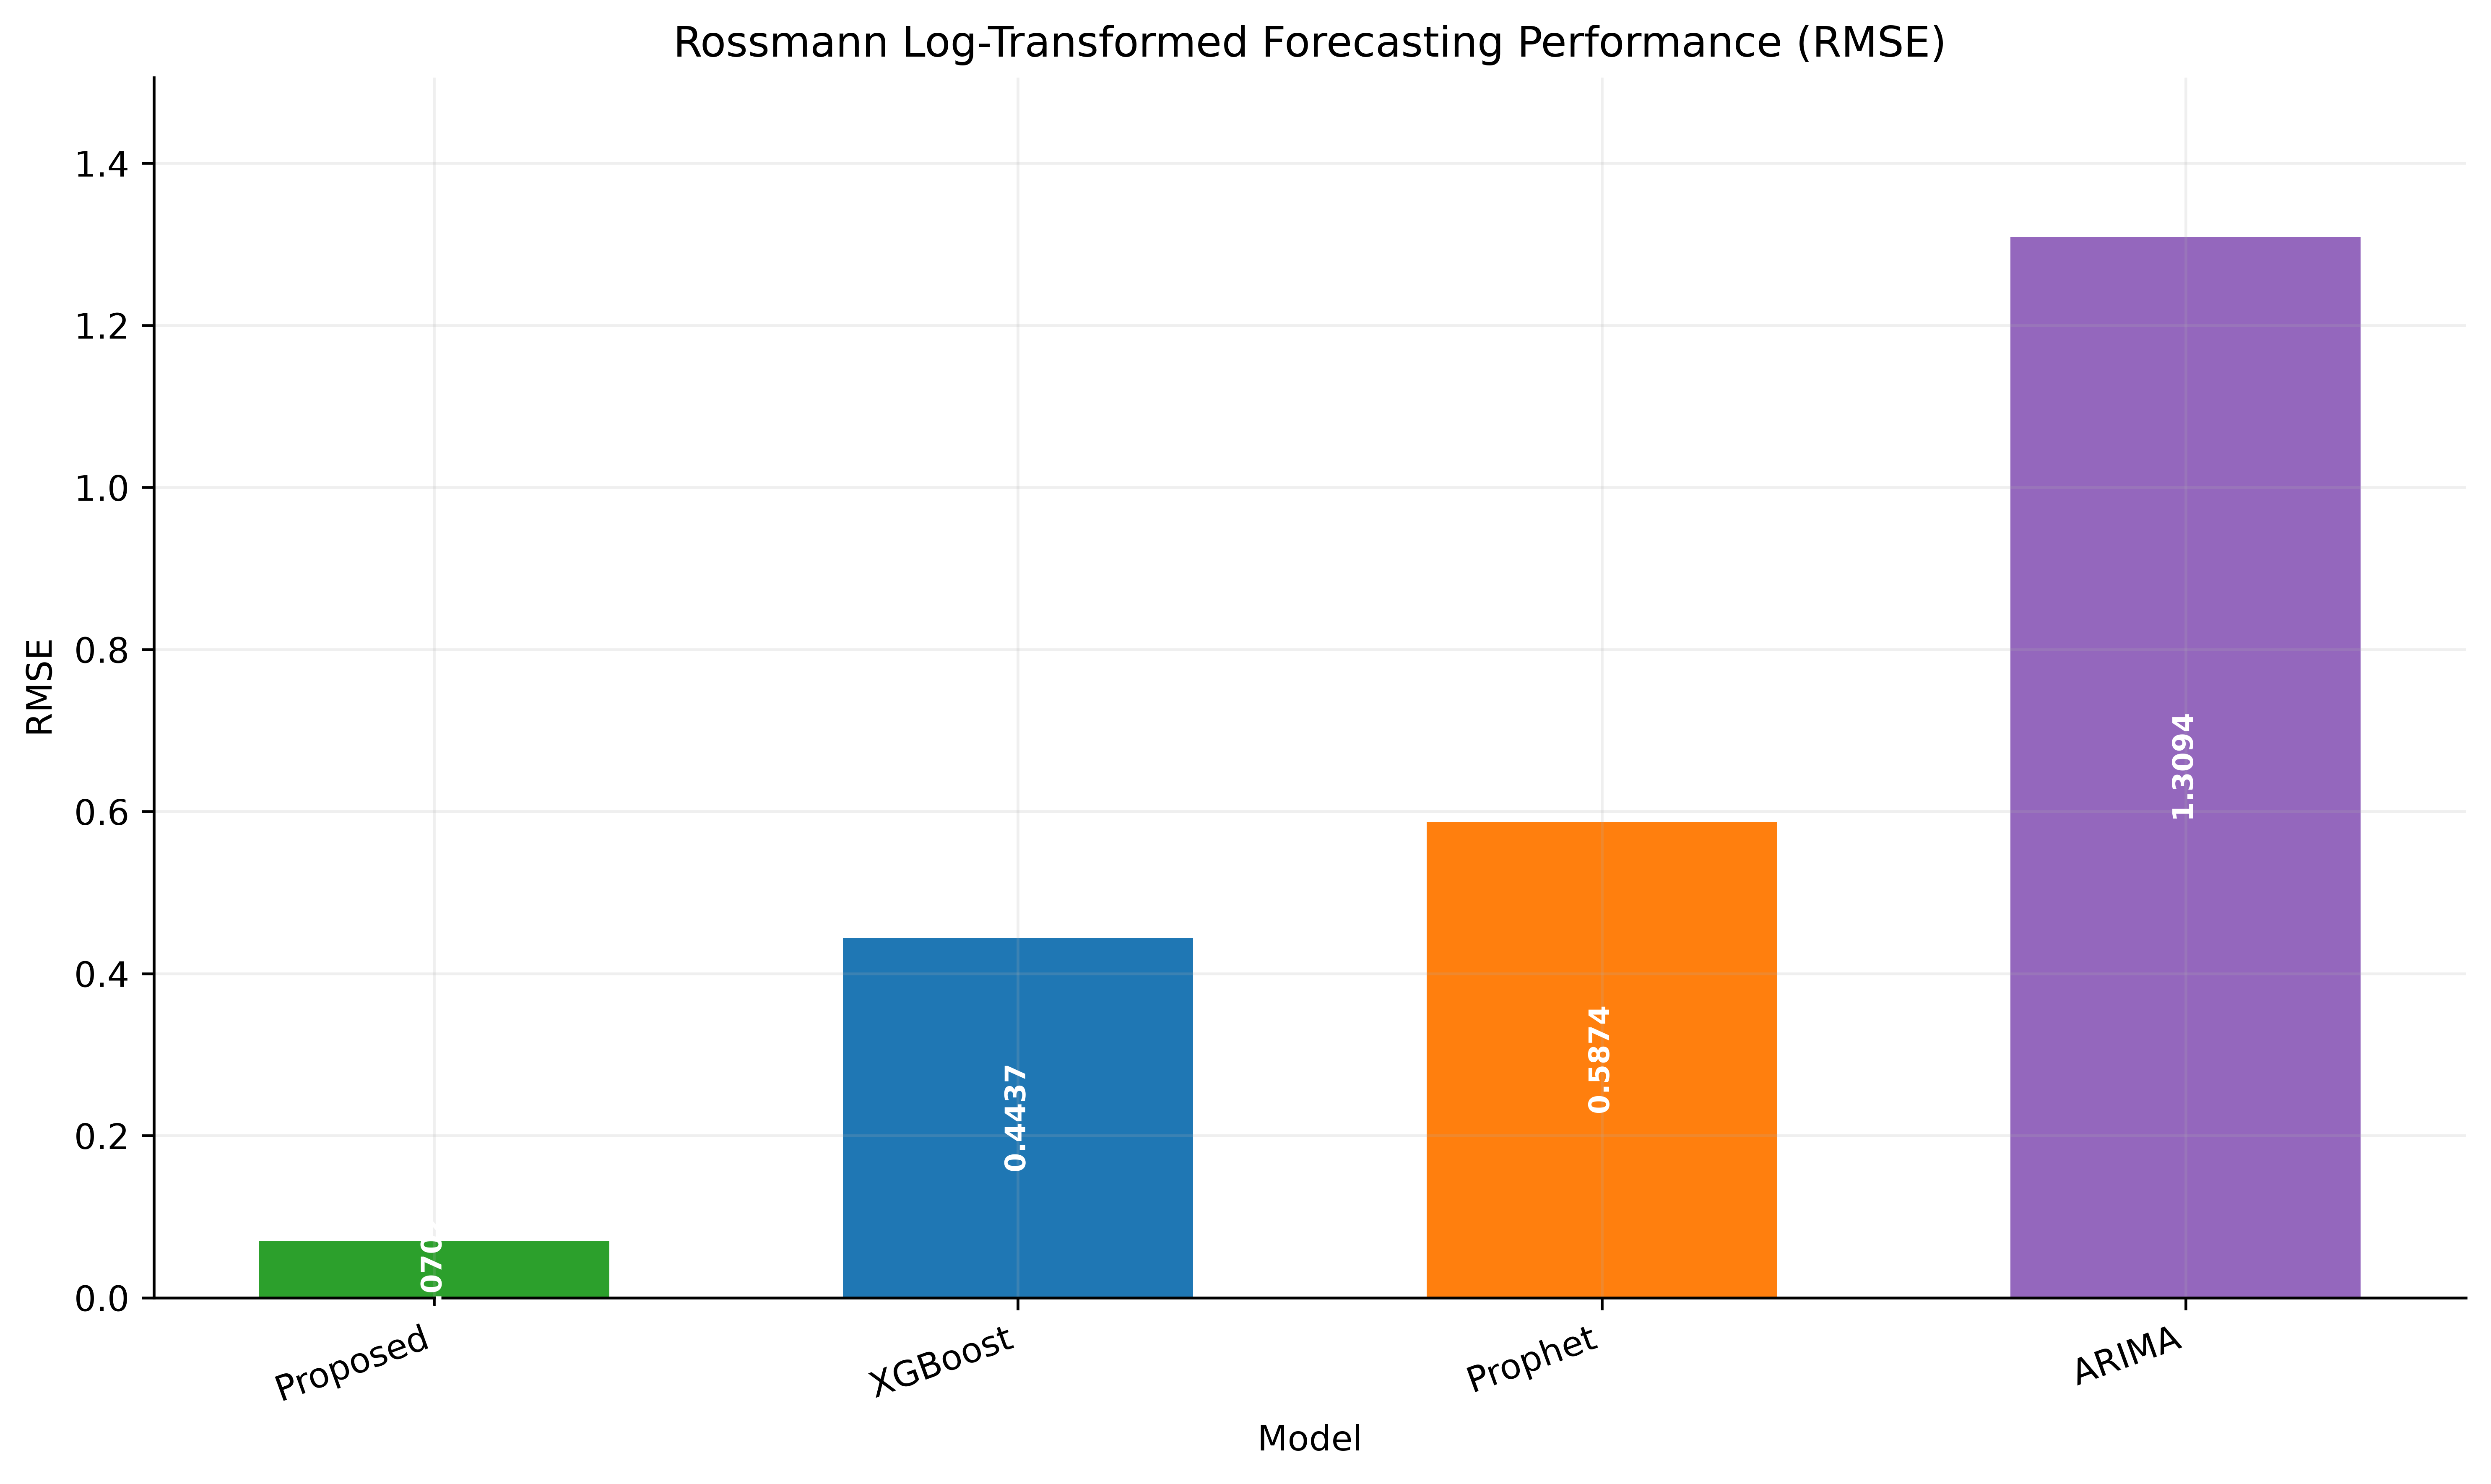

In [5]:
rossmann_scaled_rmse = pd.DataFrame({
    "Model": ["Proposed", "XGBoost", "Prophet", "ARIMA"],
    "RMSE": [0.07022, 0.4437, 0.5874, 1.3094],
})

colors = [PROPOSED_COLOR if model == "Proposed" else BASELINE_COLORS[idx % len(BASELINE_COLORS)] for idx, model in enumerate(rossmann_scaled_rmse["Model"])]
x = np.arange(len(rossmann_scaled_rmse))
fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
bars = ax.bar(x, rossmann_scaled_rmse["RMSE"], width=0.6, color=colors)
ax.set_title("Rossmann Log-Transformed Forecasting Performance (RMSE)")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(rossmann_scaled_rmse["Model"], rotation=20, ha="right")
ax.set_ylim(0, rossmann_scaled_rmse["RMSE"].max() * 1.15)
annotate_bars(ax, fmt="{:.4f}", rotation=90)
plt.tight_layout()
plt.savefig("../assets/summary/rossmann_scaled_rmse.png", bbox_inches="tight")
plt.show()
